<a href="https://colab.research.google.com/github/Pranayshukla0610/Python_Projects/blob/main/MNIST_Animals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow
!pip install keras
!pip install opencv-python
!pip install scikit-learn

In [ ]:
!pip install tensorflow-datasets

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
dataset, dataset_info = tfds.load(
    'cats_vs_dogs',
    as_supervised=True,
    with_info=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.DF0JA1_4.0.1/cats_vs_dogs-train.tfrecord-[0-9][0-9…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [ ]:
print(dataset_info)

tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='/root/tensorflow_datasets/cats_vs_dogs/4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=23262, num_shards=16>,
    },
    citation="""@Inproceedings (Conference){asirra-a-captcha-that-exploits-interest-aligned-manual-image-categorization,
    author = {Elson, Jeremy and Douceur, Jo

In [ ]:
label_names = dataset_info.features['label'].names
print(label_names)

['cat', 'dog']


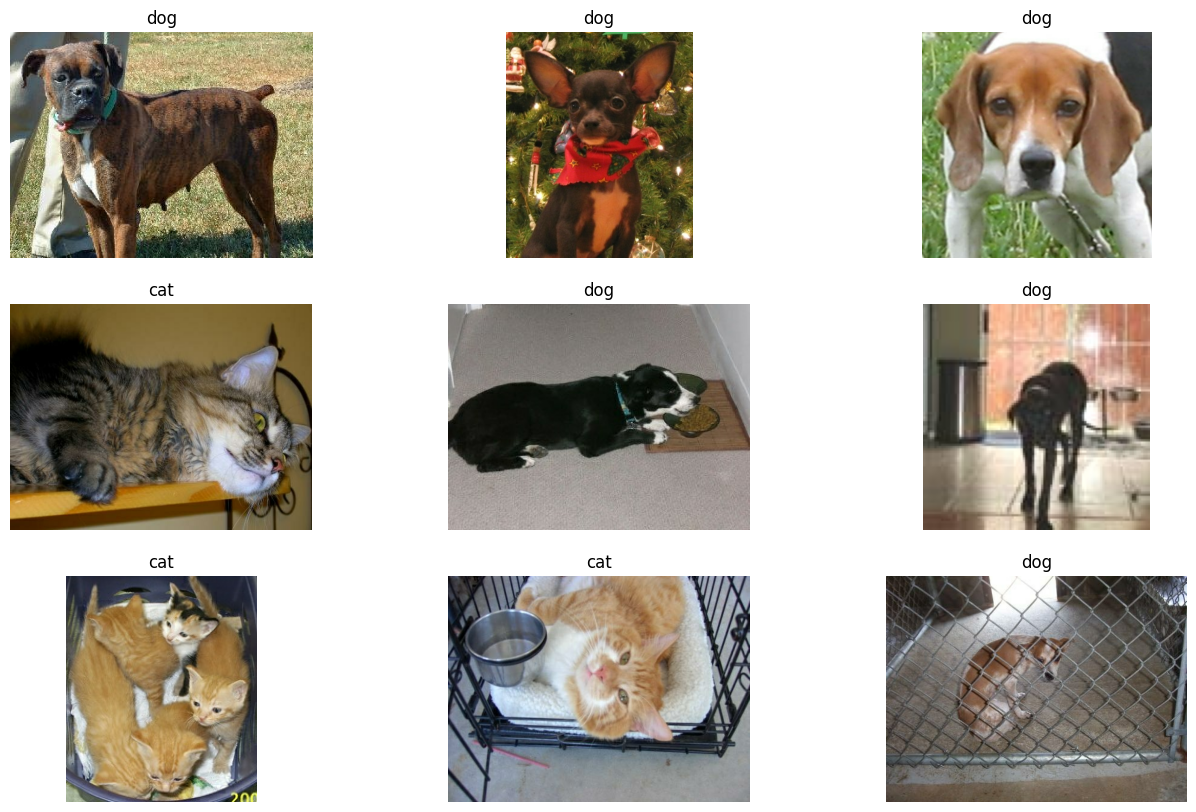

In [ ]:
train_data = dataset['train']
plt.figure(figsize=(16,10))

for i, (image, label) in enumerate(train_data.take(9)):
  plt.subplot(3,3,i+1)
  plt.imshow(image)
  plt.title(label_names[label])
  plt.axis('off')
plt.show()

In [ ]:
IMG_SIZE=128

In [ ]:
def preprocess(image, label):
  image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
  image = image/255.0
  return image, label

This preprocessing is done in almost every Deep Learning algorithm because computers do not understand images the way humans do. Images come in different sizes and contain large pixel values from 0 to 255. Neural networks learn better when all images are in the same size and when the pixel values are smaller and balanced. In your code, resize() changes every image to the same shape so the model can process them properly, and image/255.0 converts pixel values from 0–255 into 0–1, which helps the model train faster and more accurately. Without preprocessing, the model may train slowly, give poor results, or even fail during training. So preprocessing makes the data clean, consistent, and easier for the neural network to learn from.

In [ ]:
train_data = train_data.map(preprocess)

In [ ]:
DATASET_SIZE = len(train_data)

train_size = int(0.8 * DATASET_SIZE)
train_dataset = train_data.take(train_size)
test_dataset = train_data.skip(train_size)

In [ ]:
BATCH_SIZE=32

train_dataset = train_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.batch(BATCH_SIZE)

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2)
])

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [ ]:
model = Sequential([
    data_augmentation,
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=test_dataset
)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 810s 1s/step - accuracy: 0.5683 - loss: 0.6786 - val_accuracy: 0.6089 - val_loss: 0.6527
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 781s 1s/step - accuracy: 0.6480 - loss: 0.6327 - val_accuracy: 0.7021 - val_loss: 0.5685
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 734s 1s/step - accuracy: 0.6831 - loss: 0.5950 - val_accuracy: 0.7361 - val_loss: 0.5346
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 741s 1s/step - accuracy: 0.7185 - loss: 0.5544 - val_accuracy: 0.6931 - val_loss: 0.5669
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 775s 1s/step - accuracy: 0.7320 - loss: 0.5342 - val_accuracy: 0.7236 - val_loss: 0.5305
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 711s 1s/step - accuracy: 0.7451 - loss: 0.5175 - val_accuracy: 0.7662 - val_loss: 0.4897
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 705s 1s/step - accuracy: 0.7566 - loss: 0.5009 - val_accuracy: 0.7692 - val_loss: 0.4870
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 699s 1s/step - accuracy: 0.7675 - loss: 0.4849 - val_accu

In [ ]:
loss, accuracy = model.evaluate(test_dataset)
print("Accuracy:",accuracy)

146/146 ━━━━━━━━━━━━━━━━━━━━ 68s 316ms/step - accuracy: 0.8016 - loss: 0.4260
Accuracy: 0.801633358001709
